## Окружение

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import time

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Что используем: {device}")

Что используем: cuda


In [3]:
PATH = r'C:\Users\user\Documents\Deep Learning\2-3'
print(f"PATH: {PATH}")

PATH: C:\Users\user\Documents\Deep Learning\2-3


## Аугментация

In [4]:
train_augmentations = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_augmentations = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Загрузка данных

In [5]:
all_images = []
all_labels = []

In [6]:
class0_dir = os.path.join(PATH, 'класс0')
if os.path.exists(class0_dir):
    for img_name in os.listdir(class0_dir):
        if img_name.lower().endswith('.jpg'):
            all_images.append(os.path.join(class0_dir, img_name))
            all_labels.append(0)

In [7]:
class1_dir = os.path.join(PATH, 'класс1')
if os.path.exists(class1_dir):
    for img_name in os.listdir(class1_dir):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(class1_dir, img_name))
            all_labels.append(1)

In [8]:
print(f"Загружено {len(all_images)} изображений: ")
print(f"{all_labels.count(0)} класс0, {all_labels.count(1)} класс1")

Загружено 944 изображений: 
293 класс0, 651 класс1


In [9]:
transformed_images = []
for img_path in all_images:
    image = Image.open(img_path).convert('RGB')
    image = train_augmentations(image)
    transformed_images.append(image)

images_tensor = torch.stack(transformed_images)
labels_tensor = torch.tensor(all_labels)

print(f"Размер тензора изображений: {images_tensor.shape}")
print(f"Размер тензора меток: {labels_tensor.shape}")

Размер тензора изображений: torch.Size([944, 3, 224, 224])
Размер тензора меток: torch.Size([944])


In [10]:
train_size = int(0.8 * len(images_tensor))
val_size = int(0.1 * len(images_tensor))
test_size = len(images_tensor) - train_size - val_size

In [11]:
indices = torch.randperm(len(images_tensor))
train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

In [12]:
train_images = images_tensor[train_indices]
train_labels = labels_tensor[train_indices]
val_images = images_tensor[val_indices]
val_labels = labels_tensor[val_indices]
test_images = images_tensor[test_indices]
test_labels = labels_tensor[test_indices]

In [13]:
print(f"Размеры выборок: Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")

Размеры выборок: Train: 755, Val: 94, Test: 95


In [14]:
train_dataset = list(zip(train_images, train_labels))
val_dataset = list(zip(val_images, val_labels))
test_dataset = list(zip(test_images, test_labels))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

## Отрисовка графиков

In [15]:
def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
    axes[0].plot(history['val_acc'], label='Validation Accuracy', color='red', linewidth=2)
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
    axes[1].plot(history['val_loss'], label='Validation Loss', color='red', linewidth=2)
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


## Функции для помощи в вычислениях

In [16]:
def compute_accuracy(outputs, targets):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == targets).sum().item()
    total = targets.size(0)
    return correct / total

In [17]:
def validate_model(model, val_loader, criterion):
    model.eval()
    val_loss = 0.0
    val_acc = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            images, labels = batch
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_acc += compute_accuracy(outputs, labels) * images.size(0)
            total_samples += images.size(0)

    return val_loss / total_samples, val_acc / total_samples


## Модели

### Базовая CNN

In [18]:
num_epochs = 28

In [19]:
model1 = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Dropout(0.4),
    
    nn.Conv2d(32, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Dropout(0.3),
    
    nn.Conv2d(64, 128, 3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Dropout(0.4),
    
    nn.AdaptiveAvgPool2d((4, 4)),
    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, 2)
).to(device)

criterion1 = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)
scheduler1 = optim.lr_scheduler.StepLR(optimizer1, step_size=10, gamma=0.5)

history1 = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'learning_rate': []
}

best_val_acc1 = 0.0


In [20]:
for epoch in range(num_epochs):
    model1.train()
    train_loss = 0.0
    train_acc = 0.0
    total_samples = 0

    for batch in train_loader:
        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        optimizer1.zero_grad()
        outputs = model1(images)
        loss = criterion1(outputs, labels)
        loss.backward()
        optimizer1.step()

        train_loss += loss.item() * images.size(0)
        train_acc += compute_accuracy(outputs, labels) * images.size(0)
        total_samples += images.size(0)

    train_loss /= total_samples
    train_acc /= total_samples

    val_loss, val_acc = validate_model(model1, val_loader, criterion1)
    
    scheduler1.step()
    current_lr = optimizer1.param_groups[0]['lr']

    history1['train_loss'].append(train_loss)
    history1['train_acc'].append(train_acc)
    history1['val_loss'].append(val_loss)
    history1['val_acc'].append(val_acc)
    history1['learning_rate'].append(current_lr)

    print(f'Epoch {epoch+1:2d}/{num_epochs}: '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | '
          f'LR: {current_lr:.6f}')

    if val_acc > best_val_acc1:
        best_val_acc1 = val_acc
        torch.save(model1.state_dict(), 'best_model1.pth')


Epoch  1/28: Train Loss: 0.5967, Train Acc: 0.7099 | Val Loss: 0.5925, Val Acc: 0.7234 | LR: 0.001000
Epoch  2/28: Train Loss: 0.5191, Train Acc: 0.7444 | Val Loss: 0.5416, Val Acc: 0.6809 | LR: 0.001000
Epoch  3/28: Train Loss: 0.4721, Train Acc: 0.7775 | Val Loss: 0.5907, Val Acc: 0.6596 | LR: 0.001000
Epoch  4/28: Train Loss: 0.4290, Train Acc: 0.8013 | Val Loss: 0.5227, Val Acc: 0.7340 | LR: 0.001000
Epoch  5/28: Train Loss: 0.3904, Train Acc: 0.8225 | Val Loss: 0.4736, Val Acc: 0.7660 | LR: 0.001000
Epoch  6/28: Train Loss: 0.4069, Train Acc: 0.8185 | Val Loss: 0.6121, Val Acc: 0.6383 | LR: 0.001000
Epoch  7/28: Train Loss: 0.3942, Train Acc: 0.8119 | Val Loss: 0.4663, Val Acc: 0.7872 | LR: 0.001000
Epoch  8/28: Train Loss: 0.3362, Train Acc: 0.8464 | Val Loss: 0.4523, Val Acc: 0.7979 | LR: 0.001000
Epoch  9/28: Train Loss: 0.4017, Train Acc: 0.8238 | Val Loss: 0.4598, Val Acc: 0.7979 | LR: 0.001000
Epoch 10/28: Train Loss: 0.3575, Train Acc: 0.8344 | Val Loss: 0.4924, Val Acc: 0.

C:\Users\user\AppData\Local\Temp\ipykernel_1872\2194535125.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model1.load_state_dict(torch.load('best_model1.pth'))


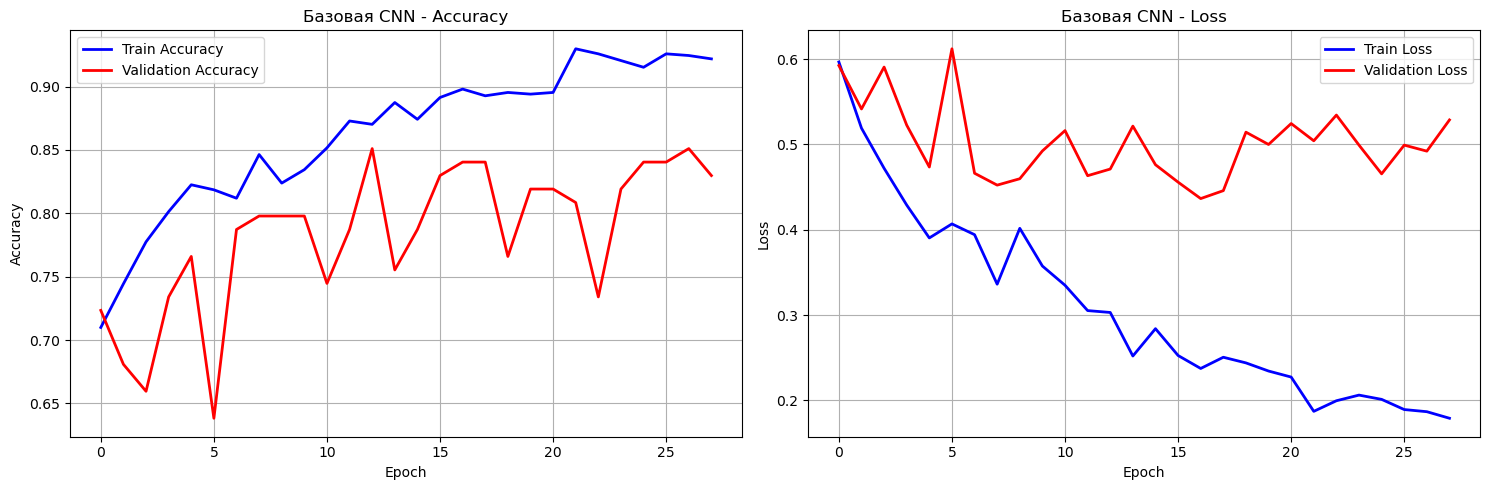

In [21]:
model1.load_state_dict(torch.load('best_model1.pth'))
plot_training_history(history1, "Базовая CNN")

### Чуть улучшенная CNN

In [22]:
model2 = nn.Sequential(
    nn.Conv2d(3, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Dropout(0.2),
    
    nn.Conv2d(64, 128, 3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Dropout(0.3),
    
    nn.Conv2d(128, 256, 3, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Dropout(0.4),
    
    nn.AdaptiveAvgPool2d((2, 2)),
    nn.Flatten(),
    nn.Linear(256 * 2 * 2, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 2)
).to(device)

criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.AdamW(model2.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler2 = optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=num_epochs)

history2 = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'learning_rate': []
}

best_val_acc2 = 0.0

In [23]:
for epoch in range(num_epochs):
    model2.train()
    train_loss = 0.0
    train_acc = 0.0
    total_samples = 0

    for batch in train_loader:
        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        optimizer2.zero_grad()
        outputs = model2(images)
        loss = criterion2(outputs, labels)
        loss.backward()
        optimizer2.step()

        train_loss += loss.item() * images.size(0)
        train_acc += compute_accuracy(outputs, labels) * images.size(0)
        total_samples += images.size(0)

    train_loss /= total_samples
    train_acc /= total_samples

    val_loss, val_acc = validate_model(model2, val_loader, criterion2)
    
    scheduler2.step()
    current_lr = optimizer2.param_groups[0]['lr']

    history2['train_loss'].append(train_loss)
    history2['train_acc'].append(train_acc)
    history2['val_loss'].append(val_loss)
    history2['val_acc'].append(val_acc)
    history2['learning_rate'].append(current_lr)

    print(f'Epoch {epoch+1:2d}/{num_epochs}: '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | '
          f'LR: {current_lr:.6f}')

    if val_acc > best_val_acc2:
        best_val_acc2 = val_acc
        torch.save(model2.state_dict(), 'best_model2.pth')


Epoch  1/28: Train Loss: 0.6322, Train Acc: 0.6755 | Val Loss: 0.5872, Val Acc: 0.7447 | LR: 0.000498
Epoch  2/28: Train Loss: 0.5767, Train Acc: 0.6954 | Val Loss: 0.5222, Val Acc: 0.7340 | LR: 0.000494
Epoch  3/28: Train Loss: 0.5806, Train Acc: 0.7126 | Val Loss: 0.5988, Val Acc: 0.7021 | LR: 0.000486
Epoch  4/28: Train Loss: 0.5467, Train Acc: 0.7285 | Val Loss: 0.5042, Val Acc: 0.7660 | LR: 0.000475
Epoch  5/28: Train Loss: 0.5382, Train Acc: 0.7391 | Val Loss: 0.6377, Val Acc: 0.5851 | LR: 0.000462
Epoch  6/28: Train Loss: 0.5277, Train Acc: 0.7152 | Val Loss: 0.4777, Val Acc: 0.8085 | LR: 0.000445
Epoch  7/28: Train Loss: 0.5071, Train Acc: 0.7682 | Val Loss: 0.4922, Val Acc: 0.7979 | LR: 0.000427
Epoch  8/28: Train Loss: 0.5080, Train Acc: 0.7510 | Val Loss: 0.6842, Val Acc: 0.5957 | LR: 0.000406
Epoch  9/28: Train Loss: 0.4934, Train Acc: 0.7709 | Val Loss: 0.4489, Val Acc: 0.7872 | LR: 0.000383
Epoch 10/28: Train Loss: 0.4918, Train Acc: 0.7629 | Val Loss: 0.4434, Val Acc: 0.

C:\Users\user\AppData\Local\Temp\ipykernel_1872\1794737959.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model2.load_state_dict(torch.load('best_model2.pth'))


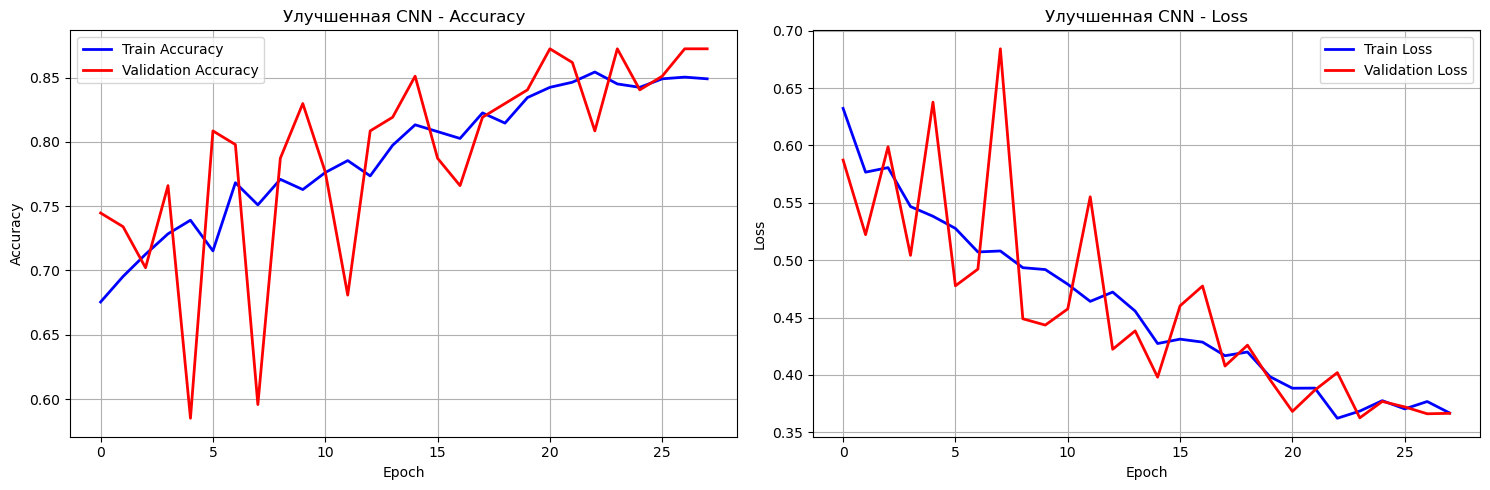

In [24]:
model2.load_state_dict(torch.load('best_model2.pth'))
plot_training_history(history2, "Улучшенная CNN")

### Широкая CNN

In [25]:
model3 = nn.Sequential(
    nn.Conv2d(3, 128, 5, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(2),
    
    nn.Conv2d(128, 256, 5, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(2),
    
    nn.Conv2d(256, 512, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    
    nn.AdaptiveAvgPool2d((4, 4)),
    nn.Flatten(),
    nn.Linear(512 * 4 * 4, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 2)
).to(device)

criterion3 = nn.CrossEntropyLoss()
optimizer3 = optim.RMSprop(model3.parameters(), lr=0.0001)
scheduler3 = optim.lr_scheduler.ReduceLROnPlateau(optimizer3, patience=3, factor=0.5)

history3 = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'learning_rate': []
}

best_val_acc3 = 0.0


In [26]:
for epoch in range(num_epochs):
    model3.train()
    train_loss = 0.0
    train_acc = 0.0
    total_samples = 0

    for batch in train_loader:
        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        optimizer3.zero_grad()
        outputs = model3(images)
        loss = criterion3(outputs, labels)
        loss.backward()
        optimizer3.step()

        train_loss += loss.item() * images.size(0)
        train_acc += compute_accuracy(outputs, labels) * images.size(0)
        total_samples += images.size(0)

    train_loss /= total_samples
    train_acc /= total_samples

    val_loss, val_acc = validate_model(model3, val_loader, criterion3)
    
    scheduler3.step(val_loss)
    current_lr = optimizer3.param_groups[0]['lr']

    history3['train_loss'].append(train_loss)
    history3['train_acc'].append(train_acc)
    history3['val_loss'].append(val_loss)
    history3['val_acc'].append(val_acc)
    history3['learning_rate'].append(current_lr)

    print(f'Epoch {epoch+1:2d}/{num_epochs}: '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | '
          f'LR: {current_lr:.6f}')

    if val_acc > best_val_acc3:
        best_val_acc3 = val_acc
        torch.save(model3.state_dict(), 'best_model3.pth')


Epoch  1/28: Train Loss: 0.6419, Train Acc: 0.6768 | Val Loss: 0.6132, Val Acc: 0.6702 | LR: 0.000100
Epoch  2/28: Train Loss: 0.5741, Train Acc: 0.6980 | Val Loss: 0.6066, Val Acc: 0.8085 | LR: 0.000100
Epoch  3/28: Train Loss: 0.5526, Train Acc: 0.7258 | Val Loss: 0.5099, Val Acc: 0.7340 | LR: 0.000100
Epoch  4/28: Train Loss: 0.5085, Train Acc: 0.7709 | Val Loss: 0.5359, Val Acc: 0.7447 | LR: 0.000100
Epoch  5/28: Train Loss: 0.4796, Train Acc: 0.7881 | Val Loss: 0.4889, Val Acc: 0.7660 | LR: 0.000100
Epoch  6/28: Train Loss: 0.4235, Train Acc: 0.8066 | Val Loss: 0.4389, Val Acc: 0.7979 | LR: 0.000100
Epoch  7/28: Train Loss: 0.3909, Train Acc: 0.8185 | Val Loss: 0.3664, Val Acc: 0.8617 | LR: 0.000100
Epoch  8/28: Train Loss: 0.3700, Train Acc: 0.8424 | Val Loss: 0.3794, Val Acc: 0.8298 | LR: 0.000100
Epoch  9/28: Train Loss: 0.3487, Train Acc: 0.8424 | Val Loss: 0.3967, Val Acc: 0.8298 | LR: 0.000100
Epoch 10/28: Train Loss: 0.3228, Train Acc: 0.8596 | Val Loss: 0.4547, Val Acc: 0.

C:\Users\user\AppData\Local\Temp\ipykernel_1872\764230788.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model3.load_state_dict(torch.load('best_model3.pth'))


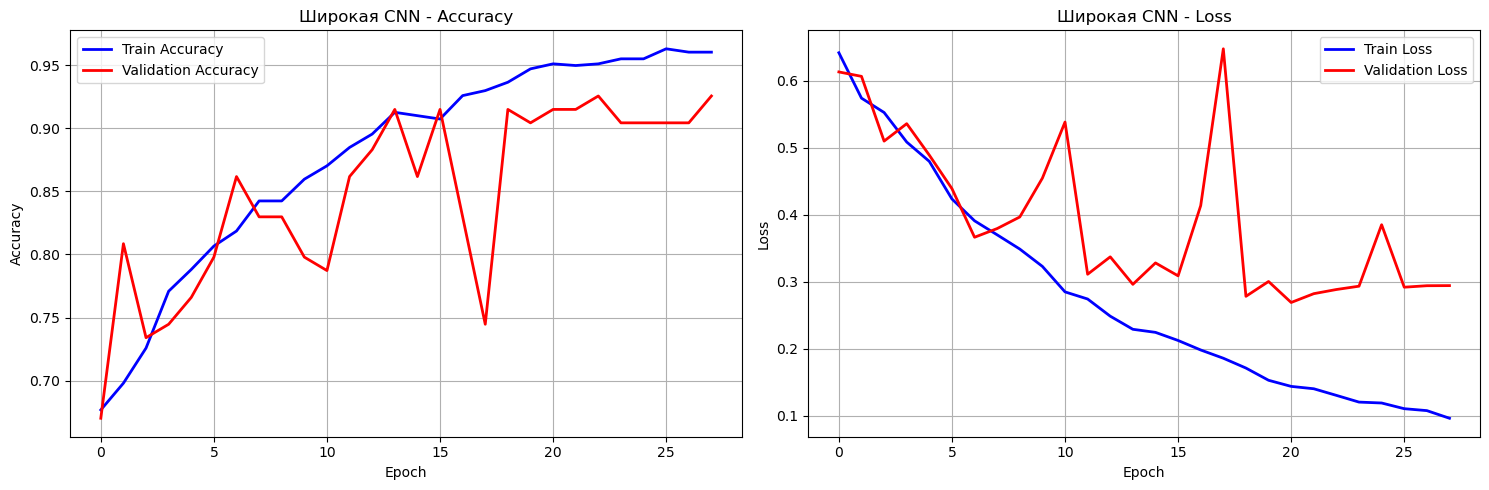

In [27]:
model3.load_state_dict(torch.load('best_model3.pth'))
plot_training_history(history3, "Широкая CNN")

### Efficientnet_v0

In [28]:
model4 = models.efficientnet_b0(pretrained=True)

for param in model4.parameters():
    param.requires_grad = False

model4.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=2)
)

model4 = model4.to(device)

criterion4 = nn.CrossEntropyLoss()
optimizer4 = optim.Adam(model4.classifier.parameters(), lr=0.001)
scheduler4 = optim.lr_scheduler.StepLR(optimizer4, step_size=5, gamma=0.5)

history4 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc4 = 0.0

C:\ProgramData\anaconda3\envs\dl-cuda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\ProgramData\anaconda3\envs\dl-cuda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [29]:
for epoch in range(num_epochs):
    model4.train()
    train_loss = 0.0
    train_acc = 0.0
    total_samples = 0

    for batch in train_loader:
        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        optimizer4.zero_grad()
        outputs = model4(images)
        loss = criterion4(outputs, labels)
        loss.backward()
        optimizer4.step()

        train_loss += loss.item() * images.size(0)
        train_acc += compute_accuracy(outputs, labels) * images.size(0)
        total_samples += images.size(0)

    train_loss /= total_samples
    train_acc /= total_samples
    val_loss, val_acc = validate_model(model4, val_loader, criterion4)
    scheduler4.step()

    history4['train_loss'].append(train_loss)
    history4['train_acc'].append(train_acc)
    history4['val_loss'].append(val_loss)
    history4['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1:2d}/{num_epochs}: '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    if val_acc > best_val_acc4:
        best_val_acc4 = val_acc
        torch.save(model4.state_dict(), 'best_model4.pth')


Epoch  1/28: Train Loss: 0.5164, Train Acc: 0.7351 | Val Loss: 0.4445, Val Acc: 0.8404
Epoch  2/28: Train Loss: 0.4158, Train Acc: 0.8212 | Val Loss: 0.3730, Val Acc: 0.8830
Epoch  3/28: Train Loss: 0.3799, Train Acc: 0.8477 | Val Loss: 0.3599, Val Acc: 0.8936
Epoch  4/28: Train Loss: 0.3561, Train Acc: 0.8424 | Val Loss: 0.3432, Val Acc: 0.8936
Epoch  5/28: Train Loss: 0.3716, Train Acc: 0.8424 | Val Loss: 0.3291, Val Acc: 0.8830
Epoch  6/28: Train Loss: 0.3252, Train Acc: 0.8715 | Val Loss: 0.3253, Val Acc: 0.8830
Epoch  7/28: Train Loss: 0.3191, Train Acc: 0.8715 | Val Loss: 0.3096, Val Acc: 0.8936
Epoch  8/28: Train Loss: 0.3105, Train Acc: 0.8702 | Val Loss: 0.3124, Val Acc: 0.8936
Epoch  9/28: Train Loss: 0.3189, Train Acc: 0.8755 | Val Loss: 0.3134, Val Acc: 0.9255
Epoch 10/28: Train Loss: 0.3112, Train Acc: 0.8689 | Val Loss: 0.3132, Val Acc: 0.8936
Epoch 11/28: Train Loss: 0.3233, Train Acc: 0.8649 | Val Loss: 0.3161, Val Acc: 0.8830
Epoch 12/28: Train Loss: 0.3197, Train Acc:

C:\Users\user\AppData\Local\Temp\ipykernel_1872\2294189121.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model4.load_state_dict(torch.load('best_model4.pth'))


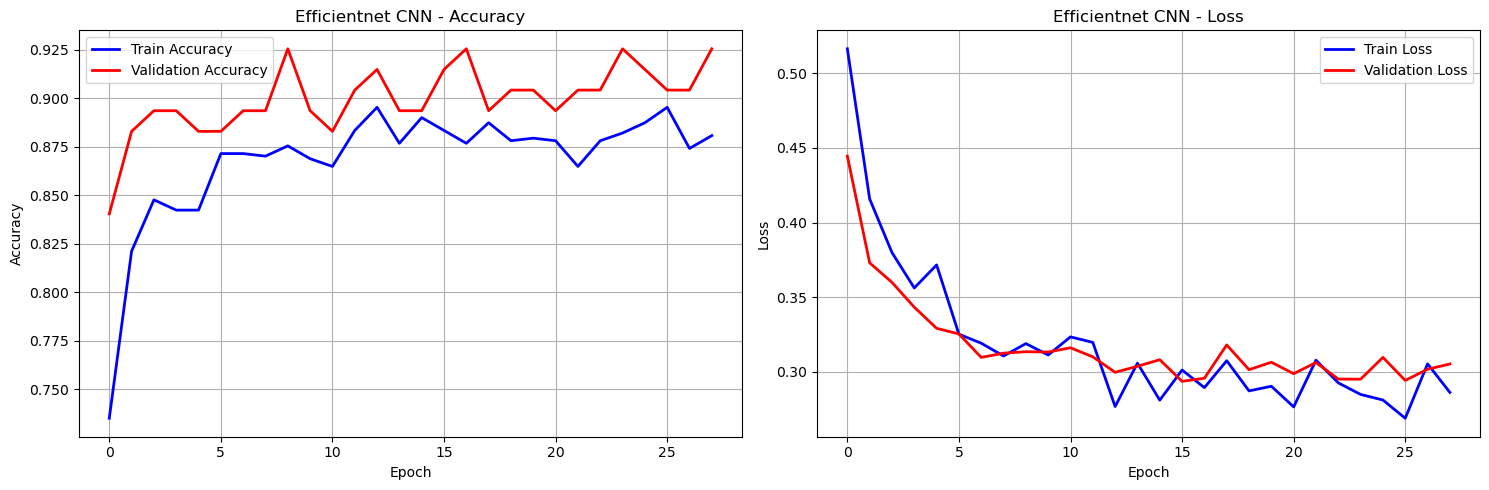

In [30]:
model4.load_state_dict(torch.load('best_model4.pth'))
plot_training_history(history4, "Efficientnet CNN")

### CNN с Residual связями

In [32]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
        
    def forward(self, x):
        residual = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        out = self.relu(out)
        return out

model5 = nn.Sequential(
    nn.Conv2d(3, 64, 7, stride=2, padding=3),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(3, stride=2, padding=1),
    
    ResidualBlock(64, 64),
    nn.MaxPool2d(2),
    
    ResidualBlock(64, 128, stride=1),
    nn.MaxPool2d(2),
    
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 2)
).to(device)


criterion5 = nn.CrossEntropyLoss()
optimizer5 = optim.Adam(model5.parameters(), lr=0.0005)
scheduler5 = optim.lr_scheduler.CosineAnnealingLR(optimizer5, T_max=num_epochs)

history5 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc5 = 0.0

Epoch  1/28: Train Loss: 0.5822, Train Acc: 0.7205 | Val Loss: 0.5597, Val Acc: 0.6702
Epoch  2/28: Train Loss: 0.5299, Train Acc: 0.7298 | Val Loss: 0.4981, Val Acc: 0.7766
Epoch  3/28: Train Loss: 0.4992, Train Acc: 0.7589 | Val Loss: 0.5041, Val Acc: 0.7766
Epoch  4/28: Train Loss: 0.4591, Train Acc: 0.7894 | Val Loss: 0.4538, Val Acc: 0.7979
Epoch  5/28: Train Loss: 0.4367, Train Acc: 0.7987 | Val Loss: 0.7265, Val Acc: 0.5426
Epoch  6/28: Train Loss: 0.4333, Train Acc: 0.8079 | Val Loss: 0.4706, Val Acc: 0.7872
Epoch  7/28: Train Loss: 0.3952, Train Acc: 0.8252 | Val Loss: 0.3664, Val Acc: 0.8830
Epoch  8/28: Train Loss: 0.3991, Train Acc: 0.8119 | Val Loss: 0.5089, Val Acc: 0.7766
Epoch  9/28: Train Loss: 0.3784, Train Acc: 0.8305 | Val Loss: 0.5125, Val Acc: 0.7340
Epoch 10/28: Train Loss: 0.3727, Train Acc: 0.8384 | Val Loss: 0.4459, Val Acc: 0.7979
Epoch 11/28: Train Loss: 0.3860, Train Acc: 0.8278 | Val Loss: 0.5046, Val Acc: 0.7447
Epoch 12/28: Train Loss: 0.3454, Train Acc:

C:\Users\user\AppData\Local\Temp\ipykernel_1872\4198202436.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model5.load_state_dict(torch.load('best_model5.pth'))


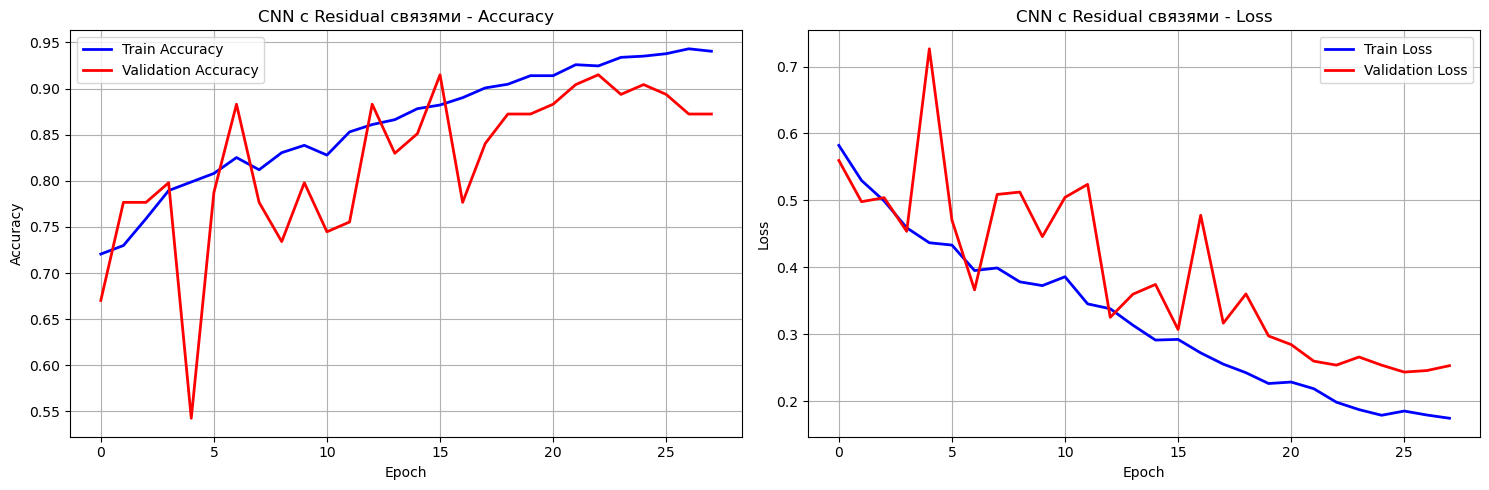

In [33]:
for epoch in range(num_epochs):
    model5.train()
    train_loss = 0.0
    train_acc = 0.0
    total_samples = 0

    for batch in train_loader:
        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        optimizer5.zero_grad()
        outputs = model5(images)
        loss = criterion5(outputs, labels)
        loss.backward()
        optimizer5.step()

        train_loss += loss.item() * images.size(0)
        train_acc += compute_accuracy(outputs, labels) * images.size(0)
        total_samples += images.size(0)

    train_loss /= total_samples
    train_acc /= total_samples
    val_loss, val_acc = validate_model(model5, val_loader, criterion5)
    scheduler5.step()

    history5['train_loss'].append(train_loss)
    history5['train_acc'].append(train_acc)
    history5['val_loss'].append(val_loss)
    history5['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1:2d}/{num_epochs}: '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    if val_acc > best_val_acc5:
        best_val_acc5 = val_acc
        torch.save(model5.state_dict(), 'best_model5.pth')

model5.load_state_dict(torch.load('best_model5.pth'))
plot_training_history(history5, "CNN с Residual связями")

In [34]:
print(f"1. Простая CNN: {best_val_acc1:.4f}")
print(f"2. Глубокая CNN с BatchNorm: {best_val_acc2:.4f}")
print(f"3. Широкая CNN: {best_val_acc3:.4f}")
print(f"4. Компактная CNN: {best_val_acc4:.4f}")
print(f"5. CNN с Residual связями: {best_val_acc5:.4f}")

1. Простая CNN: 0.8511
2. Глубокая CNN с BatchNorm: 0.8723
3. Широкая CNN: 0.9255
4. Компактная CNN: 0.9255
5. CNN с Residual связями: 0.9149


In [35]:
best_accuracy = max(best_val_acc1, best_val_acc2, best_val_acc3, best_val_acc4, best_val_acc5)
best_model_name = ""
if best_accuracy == best_val_acc1: best_model_name = "Простая CNN"
elif best_accuracy == best_val_acc2: best_model_name = "Глубокая CNN с BatchNorm"
elif best_accuracy == best_val_acc3: best_model_name = "Широкая CNN"
elif best_accuracy == best_val_acc4: best_model_name = "Компактная CNN"
else: best_model_name = "CNN с Residual связями"

In [36]:
print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ: {best_model_name} с точностью {best_accuracy:.4f}")


🏆 ЛУЧШАЯ МОДЕЛЬ: Широкая CNN с точностью 0.9255
